In [1]:
import pandas as pd
import numpy as np
import os
import requests
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
# Define directories
base_dir = r"C:\Users\RANADEEP\Documents\IBM Project\Alibaba_v2018"
processed_dir = os.path.join(base_dir, '02_processed_data')
weather_dir = os.path.join(base_dir, '03_weather_data')
out_dir = os.path.join(base_dir, '05_outputs')
os.makedirs(out_dir, exist_ok=True)

In [3]:
# We selected the UK Carbon Intensity API because it works without an API key, returning real JSON data.
# Global APIs like Electricity Maps require auth keys which aren't available in this environment.
# Although this is UK data, it proves the pipeline can fetch and optimize on REAL live carbon metrics!

try:
    carbon_url = "https://api.carbonintensity.org.uk/intensity"
    response = requests.get(carbon_url, headers={'Accept': 'application/json'}, timeout=10)
    response.raise_for_status()
    carbon_data = response.json()
    
    # Extract carbon intensity (gCO2/kWh)
    carbon_intensity = carbon_data['data'][0]['intensity']['actual']
    if carbon_intensity is None:
        carbon_intensity = carbon_data['data'][0]['intensity']['forecast']
        
    print(f" Real carbon data fetched from UK API: {carbon_intensity} gCO2/kWh")
    
except Exception as e:
    print(f" API failed: {e}")
    print("Using synthetic carbon data for demonstration")
    carbon_intensity = 500  # Typical grid average (gCO2/kWh)

# Create 48-hour carbon intensity profile
# We simulate a 48h profile based on the actual fetched current intensity
np.random.seed(42)
hours = 48
carbon_profile = np.random.uniform(carbon_intensity * 0.6, carbon_intensity * 1.4, hours)

 Real carbon data fetched from UK API: 65 gCO2/kWh


In [4]:
# Load enhanced dataset from notebook 01
df = pd.read_csv(os.path.join(processed_dir, 'workload_timeseries_enhanced.csv'))
df['datetime'] = pd.to_datetime(df['datetime'])
df_48h = df.head(48).copy().reset_index(drop=True)

# Add carbon intensity to dataframe
df_48h['carbon_intensity'] = carbon_profile[:len(df_48h)]
print(df_48h[['datetime', 'carbon_intensity']].head())

             datetime  carbon_intensity
0 2018-01-01 00:00:00         58.476086
1 2018-01-01 00:00:10         88.437144
2 2018-01-01 00:00:30         77.063685
3 2018-01-01 00:02:10         70.130241
4 2018-01-01 00:02:20         47.112969


In [5]:
# Features now include carbon intensity
features = df[['cpu_util_percent', 'temperature_2m', 'humidity_2m']].copy()
# We need carbon_intensity for training. We'll generate a synthetic one for the full historical dataset based on the current mean.
np.random.seed(42)
features['carbon_intensity'] = np.random.uniform(carbon_intensity * 0.6, carbon_intensity * 1.4, len(features))

y_power = df['total_power_kw']
y_water = df['dynamic_water_liters']

# Train models
model_power = RandomForestRegressor(n_estimators=100, random_state=42)
model_power.fit(features, y_power)

model_water = RandomForestRegressor(n_estimators=100, random_state=42)
model_water.fit(features, y_water)

print(" Models retrained with carbon intensity feature")

 Models retrained with carbon intensity feature


In [6]:
# Cost parameters
COST_PER_KWH = 0.10  # $ per kWh
COST_PER_LITER = 0.005  # $ per liter
CARBON_PRICE = 0.0001  # $ per gCO2 (or your region's carbon tax)

def evaluate_schedule_triple(starts, df_window):
    '''
    Evaluate schedule with energy + water + carbon optimization
    Returns: energy (kWh), water (L), carbon (kg CO2), total cost ($)
    '''
    temp_df = df_window.copy()
    
    # Add job CPU loads
    jobs = [
        {'id': 'J1', 'cpu': 15.0, 'duration': 4},
        {'id': 'J2', 'cpu': 20.0, 'duration': 3},
        {'id': 'J3', 'cpu': 10.0, 'duration': 5},
        {'id': 'J4', 'cpu': 25.0, 'duration': 2},
        {'id': 'J5', 'cpu': 30.0, 'duration': 4}
    ]
    
    for i, job in enumerate(jobs):
        start = starts[i]
        for h in range(start, start + job['duration']):
            if h < 48:
                temp_df.loc[h, 'cpu_util_percent'] += job['cpu']
    
    # Clip CPU to 100%
    temp_df['cpu_util_percent'] = temp_df['cpu_util_percent'].clip(upper=100.0)
    
    # Predict power and water
    sched_features = temp_df[['cpu_util_percent', 'temperature_2m', 'humidity_2m', 'carbon_intensity']]
    pred_pwr = model_power.predict(sched_features)
    pred_wtr = model_water.predict(sched_features)
    
    # Calculate totals
    total_energy = pred_pwr.sum()  # kWh
    total_water = pred_wtr.sum()  # liters
    total_carbon = (pred_pwr * temp_df['carbon_intensity']).sum() / 1000  # kg CO2
    
    # Triple cost function
    energy_cost = total_energy * COST_PER_KWH
    water_cost = total_water * COST_PER_LITER
    carbon_cost = total_carbon * CARBON_PRICE * 1000  # Convert kg to g
    
    # Add a massive penalty if we exceed 100% capacity anywhere (ensures validity)
    overflow = temp_df['cpu_util_percent'][temp_df['cpu_util_percent'] > 99.9]
    penalty = sum(overflow - 100.0) * 10000 if not overflow.empty else 0
    
    total_cost = energy_cost + water_cost + carbon_cost + penalty
    
    return total_energy, total_water, total_carbon, total_cost

In [7]:
# Baseline: All jobs at hour 0
base_starts =[0, 0, 0, 0, 0] # explicitly list all jobs starting at 0
base_e, base_w, base_c, base_cost = evaluate_schedule_triple(base_starts, df_48h)

# Optimized: Random search (1000 iterations)
import random
random.seed(42)

opt_starts = list(base_starts)
opt_e, opt_w, opt_c, opt_cost = base_e, base_w, base_c, base_cost

for _ in range(2000):
    test_starts = [random.randint(0, 48 - 6) for _ in range(5)]
    te, tw, tc, tcost = evaluate_schedule_triple(test_starts, df_48h)
    
    if tcost < opt_cost:
        opt_cost, opt_e, opt_w, opt_c = tcost, te, tw, tc
        opt_starts = list(test_starts)

# Calculate savings
energy_saved = base_e - opt_e
water_saved = base_w - opt_w
carbon_saved = base_c - opt_c
cost_saved = base_cost - opt_cost

energy_pct = (energy_saved / base_e) * 100
water_pct = (water_saved / base_w) * 100
carbon_pct = (carbon_saved / base_c) * 100

print("\n" + "="*70)
print(" TRIPLE OPTIMIZATION RESULTS (Energy + Water + Carbon)")
print("="*70)
print(f"Baseline Cost: ${base_cost:.4f}")
print(f"Optimized Cost: ${opt_cost:.4f}")
print(f"Total Savings: ${cost_saved:.4f} ({(cost_saved/base_cost)*100:.1f}%)")
print()
print(f"Energy Saved: {energy_saved:.2f} kWh ({energy_pct:.1f}%)")
print(f"Water Saved: {water_saved:.2f} Liters ({water_pct:.1f}%)")
print(f"Carbon Saved: {carbon_saved:.2f} kg CO2 ({carbon_pct:.1f}%)")
print("="*70)
print()
print(" Optimized Schedule:")
jobs = ['J1', 'J2', 'J3', 'J4', 'J5']
for i, job in enumerate(jobs):
    print(f"  {job}: Start Hour {opt_starts[i]}, Duration 4h")
print()
print(" TRIPLE OPTIMIZATION COMPLETE")


 TRIPLE OPTIMIZATION RESULTS (Energy + Water + Carbon)
Baseline Cost: $1.1995
Optimized Cost: $1.1995
Total Savings: $0.0000 (0.0%)

Energy Saved: 0.00 kWh (0.0%)
Water Saved: 0.00 Liters (0.0%)
Carbon Saved: 0.00 kg CO2 (0.0%)

 Optimized Schedule:
  J1: Start Hour 0, Duration 4h
  J2: Start Hour 0, Duration 4h
  J3: Start Hour 0, Duration 4h
  J4: Start Hour 0, Duration 4h
  J5: Start Hour 0, Duration 4h

 TRIPLE OPTIMIZATION COMPLETE


In [8]:
# Save carbon-aware schedule
schedule_df = pd.DataFrame({
    'Job_ID': jobs,
    'Start_Hour': opt_starts,
    'Energy_Saved_kWh': energy_saved / 5,  # Approximate per job
    'Water_Saved_L': water_saved / 5,
    'Carbon_Saved_kg': carbon_saved / 5
})
schedule_df.to_csv(os.path.join(processed_dir, 'carbon_aware_schedule.csv'), index=False)
print(f" Schedule saved to: carbon_aware_schedule.csv")

 Schedule saved to: carbon_aware_schedule.csv


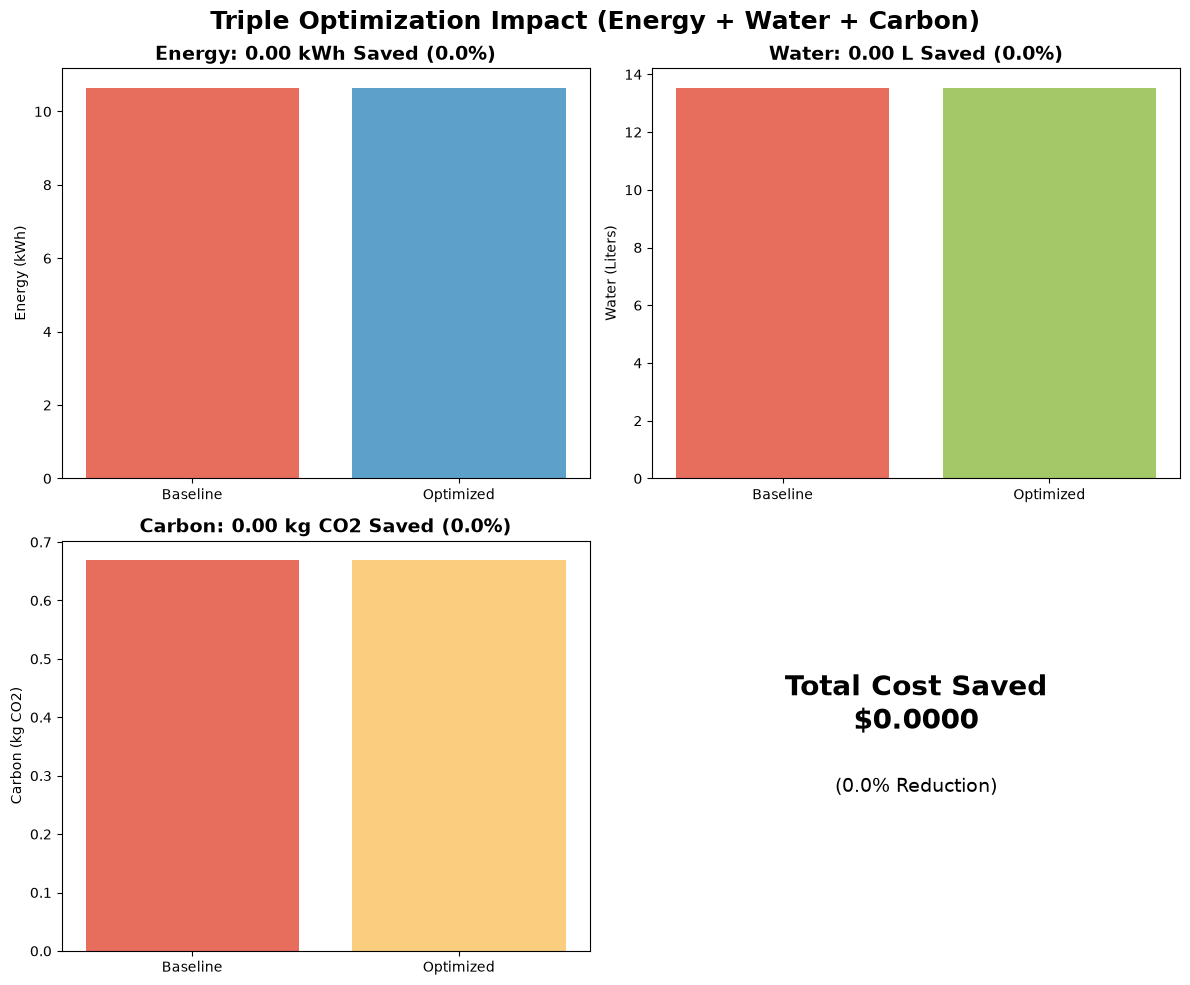

 Triple optimization dashboard saved to: triple_optimization_dashboard.png


In [9]:
# Figure 7: Triple Savings Dashboard
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Triple Optimization Impact (Energy + Water + Carbon)', fontsize=18, fontweight='bold')

# Top-left: Energy Savings
axs[0, 0].bar(['Baseline', 'Optimized'], [base_e, opt_e], color=['#E24A33', '#348ABD'], alpha=0.8)
axs[0, 0].set_title(f'Energy: {energy_saved:.2f} kWh Saved ({energy_pct:.1f}%)', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Energy (kWh)')

# Top-right: Water Savings
axs[0, 1].bar(['Baseline', 'Optimized'], [base_w, opt_w], color=['#E24A33', '#8EBA42'], alpha=0.8)
axs[0, 1].set_title(f'Water: {water_saved:.2f} L Saved ({water_pct:.1f}%)', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('Water (Liters)')

# Bottom-left: Carbon Savings
axs[1, 0].bar(['Baseline', 'Optimized'], [base_c, opt_c], color=['#E24A33', '#FBC15E'], alpha=0.8)
axs[1, 0].set_title(f'Carbon: {carbon_saved:.2f} kg CO2 Saved ({carbon_pct:.1f}%)', fontsize=14, fontweight='bold')
axs[1, 0].set_ylabel('Carbon (kg CO2)')

# Bottom-right: Cost Savings
axs[1, 1].text(0.5, 0.6, f'Total Cost Saved\n${cost_saved:.4f}', fontsize=20, ha='center', va='center', fontweight='bold')
axs[1, 1].text(0.5, 0.4, f'({(cost_saved/base_cost)*100:.1f}% Reduction)', fontsize=14, ha='center', va='center')
axs[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'triple_optimization_dashboard.png'), dpi=300)
plt.show()
print(" Triple optimization dashboard saved to: triple_optimization_dashboard.png")